<a href="https://colab.research.google.com/github/henil7781/C-/blob/main/ComputerVisionCH1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CAMERA CALIBRATION USING OPENCV
# ============================================================

# OpenCV
# Used for image processing and camera calibration
import cv2

# NumPy
# Used for arrays, matrices and mathematical operations
import numpy as np

# os
# Used for working with folders and file paths
import os

# glob
# Used to find multiple image files from a folder
import glob

# Matplotlib
# Used to display images in Google Colab
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import files

# Upload your chessboard calibration images
uploaded = files.upload()

print("Uploaded files:")
for filename in uploaded.keys():
    print(filename)

Saving left05.jpg to left05.jpg
Saving left04.jpg to left04.jpg
Saving left03.jpg to left03.jpg
Saving left02.jpg to left02.jpg
Saving left01.jpg to left01 (1).jpg
Uploaded files:
left05.jpg
left04.jpg
left03.jpg
left02.jpg
left01 (1).jpg


In [ ]:
# Find all JPG images in the current Colab directory
images = glob.glob("*.jpg")

# Also search for PNG images
images += glob.glob("*.png")

print("Number of images:", len(images))

print("\nImages:")
for image in images:
    print(image)

Number of images: 6

Images:
left05.jpg
left01.jpg
left01 (1).jpg
left04.jpg
left03.jpg
left02.jpg


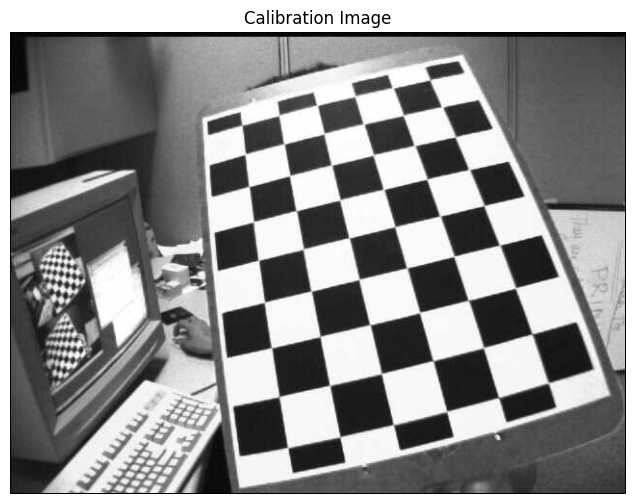

In [ ]:
# Select the first uploaded image
image = cv2.imread(images[0])

# OpenCV reads images in BGR format.
# Matplotlib expects RGB format.
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display image
plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Calibration Image")
plt.show()

In [ ]:
# ============================================================
# CHESSBOARD CONFIGURATION
# ============================================================

# Number of INNER corners in the chessboard
CHECKERBOARD = (6, 9)

print("Chessboard inner corners:", CHECKERBOARD)

Chessboard inner corners: (6, 9)


In [ ]:
# ============================================================
# CHESSBOARD CONFIGURATION
# ============================================================

# Number of INNER corners in the chessboard
CHECKERBOARD = (6, 9)

print("Chessboard inner corners:", CHECKERBOARD)

Chessboard inner corners: (6, 9)


In [ ]:
# ============================================================
# CORNER REFINEMENT CRITERIA
# ============================================================

criteria = (
    cv2.TERM_CRITERIA_EPS +
    cv2.TERM_CRITERIA_MAX_ITER,
    30,
    0.001
)

print("Calibration criteria created.")

Calibration criteria created.


In [ ]:
# ============================================================
# CREATE STORAGE FOR CALIBRATION POINTS
# ============================================================

# 3D points from the real-world chessboard
threedpoints = []

# 2D points detected in the image
twodpoints = []

print("Point storage created.")

Point storage created.


In [ ]:
# ============================================================
# CREATE 3D OBJECT POINTS
# ============================================================

# Create an array of zeros.
#
# Shape:
# 1 × (6*9) × 3
#
# 6*9 = 54 chessboard corner points
#
# Each point has:
# X, Y, Z
#
objectp3d = np.zeros(
    (1, CHECKERBOARD[0] * CHECKERBOARD[1], 3),
    np.float32
)

# Generate X and Y coordinates.
#
# Since the chessboard is flat,
# Z = 0 for every point.
#
objectp3d[0, :, :2] = np.mgrid[
    0:CHECKERBOARD[0],
    0:CHECKERBOARD[1]
].T.reshape(-1, 2)

print("3D chessboard points:")
print(objectp3d)

3D chessboard points:
[[[0. 0. 0.]
  [1. 0. 0.]
  [2. 0. 0.]
  [3. 0. 0.]
  [4. 0. 0.]
  [5. 0. 0.]
  [0. 1. 0.]
  [1. 1. 0.]
  [2. 1. 0.]
  [3. 1. 0.]
  [4. 1. 0.]
  [5. 1. 0.]
  [0. 2. 0.]
  [1. 2. 0.]
  [2. 2. 0.]
  [3. 2. 0.]
  [4. 2. 0.]
  [5. 2. 0.]
  [0. 3. 0.]
  [1. 3. 0.]
  [2. 3. 0.]
  [3. 3. 0.]
  [4. 3. 0.]
  [5. 3. 0.]
  [0. 4. 0.]
  [1. 4. 0.]
  [2. 4. 0.]
  [3. 4. 0.]
  [4. 4. 0.]
  [5. 4. 0.]
  [0. 5. 0.]
  [1. 5. 0.]
  [2. 5. 0.]
  [3. 5. 0.]
  [4. 5. 0.]
  [5. 5. 0.]
  [0. 6. 0.]
  [1. 6. 0.]
  [2. 6. 0.]
  [3. 6. 0.]
  [4. 6. 0.]
  [5. 6. 0.]
  [0. 7. 0.]
  [1. 7. 0.]
  [2. 7. 0.]
  [3. 7. 0.]
  [4. 7. 0.]
  [5. 7. 0.]
  [0. 8. 0.]
  [1. 8. 0.]
  [2. 8. 0.]
  [3. 8. 0.]
  [4. 8. 0.]
  [5. 8. 0.]]]


Processing: left05.jpg


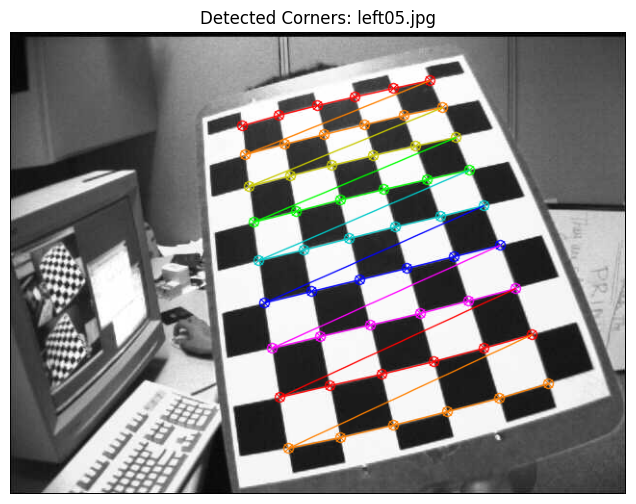

Corners detected successfully!
------------------------------------------------------------
Processing: left01.jpg


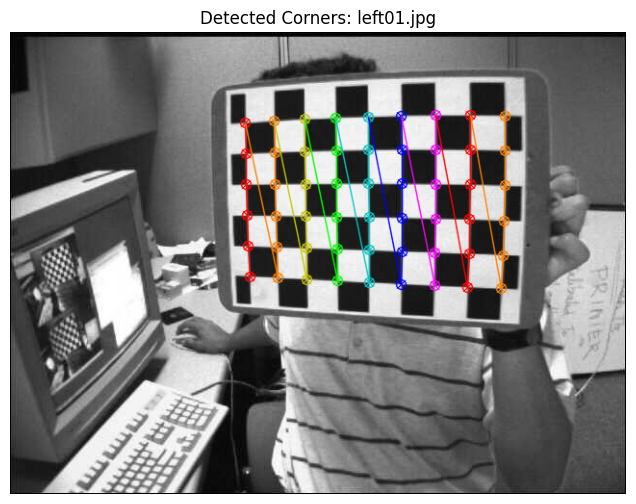

Corners detected successfully!
------------------------------------------------------------
Processing: left01 (1).jpg


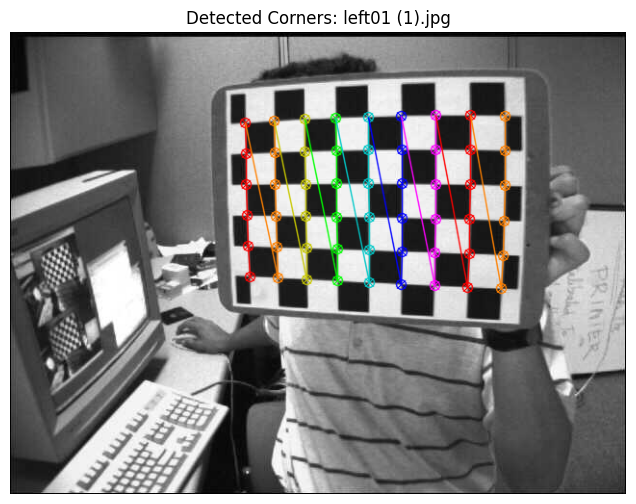

Corners detected successfully!
------------------------------------------------------------
Processing: left04.jpg


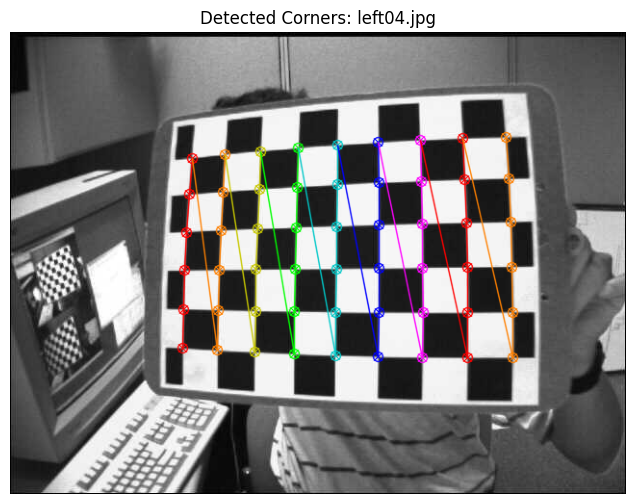

Corners detected successfully!
------------------------------------------------------------
Processing: left03.jpg


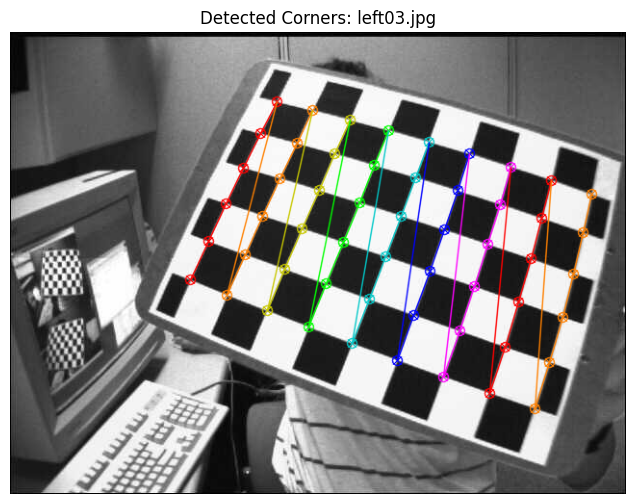

Corners detected successfully!
------------------------------------------------------------
Processing: left02.jpg


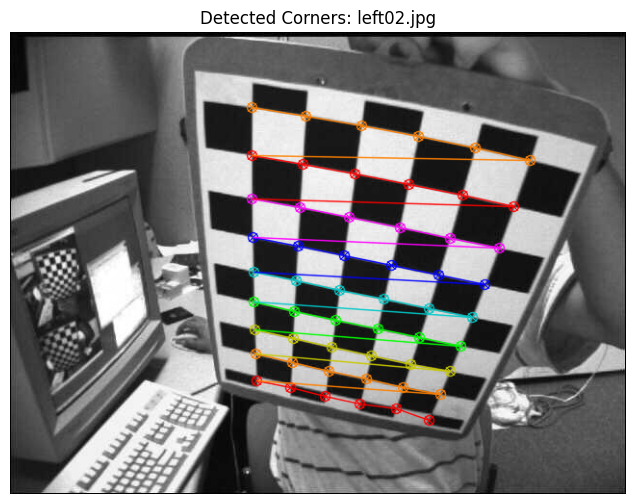

Corners detected successfully!
------------------------------------------------------------

Total successful calibration images: 6


In [ ]:
# ============================================================
# FIND CHESSBOARD CORNERS
# ============================================================

# Store the original image size
prev_img_shape = None

# Loop through every uploaded calibration image
for filename in images:

    print("Processing:", filename)

    # --------------------------------------------------------
    # 1. LOAD IMAGE
    # --------------------------------------------------------
    image = cv2.imread(filename)

    # Check whether image was loaded successfully
    if image is None:
        print("Could not load:", filename)
        continue

    # --------------------------------------------------------
    # 2. CONVERT TO GRAYSCALE
    # --------------------------------------------------------
    grayColor = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    # --------------------------------------------------------
    # 3. FIND CHESSBOARD CORNERS
    # --------------------------------------------------------
    ret, corners = cv2.findChessboardCorners(
        grayColor,
        CHECKERBOARD,
        cv2.CALIB_CB_ADAPTIVE_THRESH
        + cv2.CALIB_CB_FAST_CHECK
        + cv2.CALIB_CB_NORMALIZE_IMAGE
    )

    # --------------------------------------------------------
    # 4. CHECK WHETHER CORNERS WERE FOUND
    # --------------------------------------------------------
    if ret == True:

        # Add the known 3D chessboard coordinates
        threedpoints.append(objectp3d)

        # ----------------------------------------------------
        # 5. REFINE CORNER LOCATIONS
        # ----------------------------------------------------
        corners2 = cv2.cornerSubPix(
            grayColor,
            corners,
            (11, 11),
            (-1, -1),
            criteria
        )

        # Add detected 2D points
        twodpoints.append(corners2)

        # ----------------------------------------------------
        # 6. DRAW THE DETECTED CORNERS
        # ----------------------------------------------------
        image_with_corners = cv2.drawChessboardCorners(
            image,
            CHECKERBOARD,
            corners2,
            ret
        )

        # Convert BGR → RGB for Matplotlib
        image_rgb = cv2.cvtColor(
            image_with_corners,
            cv2.COLOR_BGR2RGB
        )

        # Display result
        plt.figure(figsize=(8, 6))
        plt.imshow(image_rgb)
        plt.title(f"Detected Corners: {filename}")
        plt.axis("off")
        plt.show()

        print("Corners detected successfully!")

    else:

        print("Chessboard corners NOT detected.")

    print("-" * 60)

print("\nTotal successful calibration images:", len(threedpoints))

In [ ]:
# ============================================================
# CHECK CALIBRATION DATA
# ============================================================

print("Number of 3D point sets:", len(threedpoints))
print("Number of 2D point sets:", len(twodpoints))

if len(threedpoints) == len(twodpoints):
    print("3D and 2D point sets match.")
else:
    print("ERROR: Number of 3D and 2D point sets do not match.")

Number of 3D point sets: 12
Number of 2D point sets: 12
3D and 2D point sets match.


In [ ]:
# ============================================================
# CAMERA CALIBRATION
# ============================================================

# Make sure that at least one successful image was found
if len(threedpoints) == 0 or len(twodpoints) == 0:
    raise ValueError(
        "No chessboard corners were detected. "
        "Check your images and CHECKERBOARD size."
    )

# Get image dimensions
h, w = grayColor.shape[:2]

# ------------------------------------------------------------
# PERFORM CAMERA CALIBRATION
# ------------------------------------------------------------

ret, matrix, distortion, r_vecs, t_vecs = cv2.calibrateCamera(
    threedpoints,
    twodpoints,
    grayColor.shape[::-1],
    None,
    None
)

print("Camera calibration completed!")

Camera calibration completed!


In [ ]:
# ============================================================
# DISTORTION COEFFICIENTS
# ============================================================

print("Distortion Coefficients:")
print(distortion)

Distortion Coefficients:
[[-0.26230212  0.0140131   0.00322927 -0.00170169  0.05681219]]


In [ ]:
# ============================================================
# CAMERA MATRIX / INTRINSIC PARAMETERS
# ============================================================

print("Camera Matrix:")
print(matrix)

Camera Matrix:
[[538.92381364   0.         337.66739192]
 [  0.         539.07914366 237.638384  ]
 [  0.           0.           1.        ]]


In [ ]:
# ============================================================
# ROTATION VECTORS
# ============================================================

print("Rotation Vectors:")

for i, rvec in enumerate(r_vecs):
    print(f"\nImage {i + 1}:")
    print(rvec)

Rotation Vectors:

Image 1:
[[-0.47199884]
 [ 0.09897433]
 [-0.22391311]]

Image 2:
[[-0.08980372]
 [ 0.35578427]
 [-1.54160139]]

Image 3:
[[-0.08980372]
 [ 0.35578427]
 [-1.54160139]]

Image 4:
[[-0.28051034]
 [ 0.11238164]
 [-1.56135876]]

Image 5:
[[-0.35057208]
 [-0.0574169 ]
 [-1.19944017]]

Image 6:
[[-0.23604992]
 [ 1.02556864]
 [-2.79328646]]

Image 7:
[[-0.47199884]
 [ 0.09897433]
 [-0.22391311]]

Image 8:
[[-0.08980372]
 [ 0.35578427]
 [-1.54160139]]

Image 9:
[[-0.08980372]
 [ 0.35578427]
 [-1.54160139]]

Image 10:
[[-0.28051034]
 [ 0.11238164]
 [-1.56135876]]

Image 11:
[[-0.35057208]
 [-0.0574169 ]
 [-1.19944017]]

Image 12:
[[-0.23604992]
 [ 1.02556864]
 [-2.79328646]]


In [ ]:
# ============================================================
# TRANSLATION VECTORS
# ============================================================

print("Translation Vectors:")

for i, tvec in enumerate(t_vecs):
    print(f"\nImage {i + 1}:")
    print(tvec)

Translation Vectors:

Image 1:
[[-2.40219817]
 [-3.47999479]
 [12.93474765]]

Image 2:
[[-2.8132318 ]
 [ 0.50550531]
 [16.93496379]]

Image 3:
[[-2.8132318 ]
 [ 0.50550531]
 [16.93496379]]

Image 4:
[[-3.87882105]
 [ 2.22558597]
 [12.80882628]]

Image 5:
[[-3.32337134]
 [ 0.44125881]
 [11.66161716]]

Image 6:
[[ 2.65673994]
 [ 4.25650279]
 [13.78003308]]

Image 7:
[[-2.40219817]
 [-3.47999479]
 [12.93474765]]

Image 8:
[[-2.8132318 ]
 [ 0.50550531]
 [16.93496379]]

Image 9:
[[-2.8132318 ]
 [ 0.50550531]
 [16.93496379]]

Image 10:
[[-3.87882105]
 [ 2.22558597]
 [12.80882628]]

Image 11:
[[-3.32337134]
 [ 0.44125881]
 [11.66161716]]

Image 12:
[[ 2.65673994]
 [ 4.25650279]
 [13.78003308]]


In [ ]:
# ============================================================
# DISPLAY ALL CALIBRATION RESULTS
# ============================================================

print("=" * 60)
print("             CAMERA CALIBRATION RESULTS")
print("=" * 60)

print("\n1. Reprojection Error / RMS Error:")
print(ret)

print("\n2. Camera Matrix:")
print(matrix)

print("\n3. Distortion Coefficients:")
print(distortion)

print("\n4. Number of Rotation Vectors:")
print(len(r_vecs))

print("\n5. Number of Translation Vectors:")
print(len(t_vecs))

print("=" * 60)

             CAMERA CALIBRATION RESULTS

1. Reprojection Error / RMS Error:
0.5145033591439184

2. Camera Matrix:
[[538.92381364   0.         337.66739192]
 [  0.         539.07914366 237.638384  ]
 [  0.           0.           1.        ]]

3. Distortion Coefficients:
[[-0.26230212  0.0140131   0.00322927 -0.00170169  0.05681219]]

4. Number of Rotation Vectors:
12

5. Number of Translation Vectors:
12


In [ ]:
print("RMS Reprojection Error:", ret)

RMS Reprojection Error: 0.5145033591439184


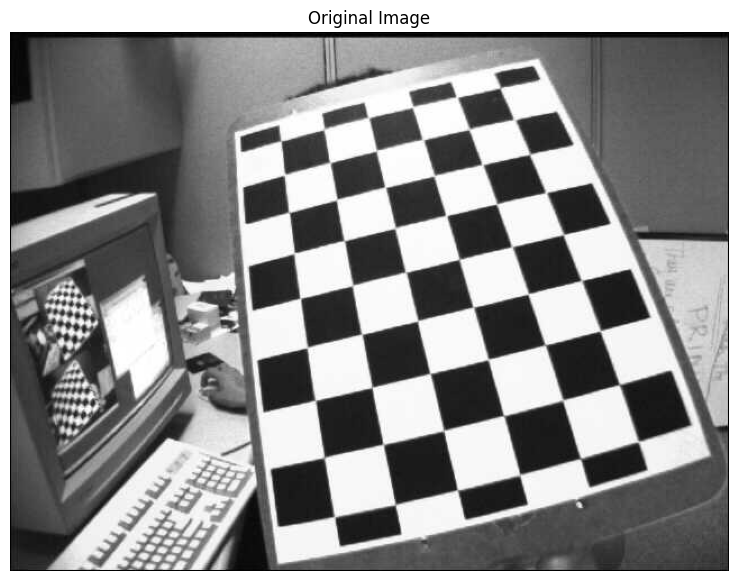

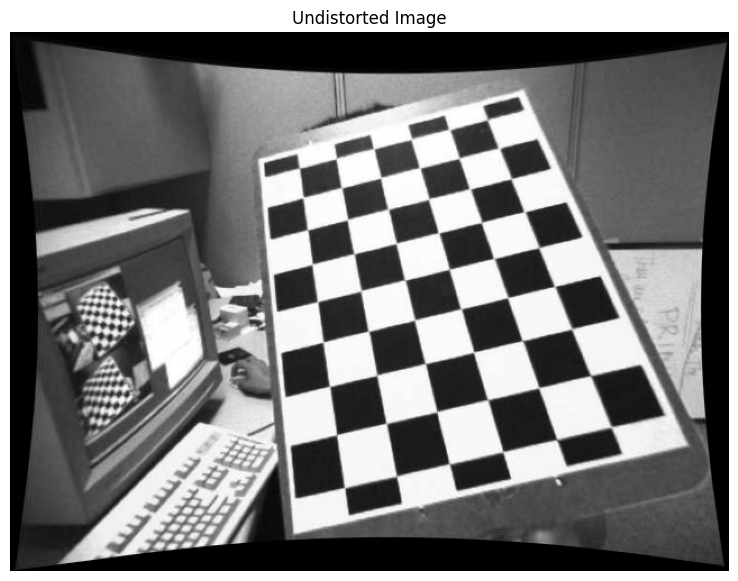

In [ ]:
# ============================================================
# UNDISTORT AN IMAGE
# ============================================================

# Select one original image
img = cv2.imread(images[0])

# ------------------------------------------------------------
# Get optimal camera matrix
# ------------------------------------------------------------

newcameramtx, roi = cv2.getOptimalNewCameraMatrix(
    matrix,
    distortion,
    (w, h),
    1,
    (w, h)
)

# ------------------------------------------------------------
# Undistort image
# ------------------------------------------------------------

dst = cv2.undistort(
    img,
    matrix,
    distortion,
    None,
    newcameramtx
)

# ------------------------------------------------------------
# Convert images BGR → RGB
# ------------------------------------------------------------

img_rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

dst_rgb = cv2.cvtColor(
    dst,
    cv2.COLOR_BGR2RGB
)

# ------------------------------------------------------------
# Display original image
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.show()

# ------------------------------------------------------------
# Display undistorted image
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

plt.imshow(dst_rgb)
plt.title("Undistorted Image")
plt.axis("off")

plt.show()

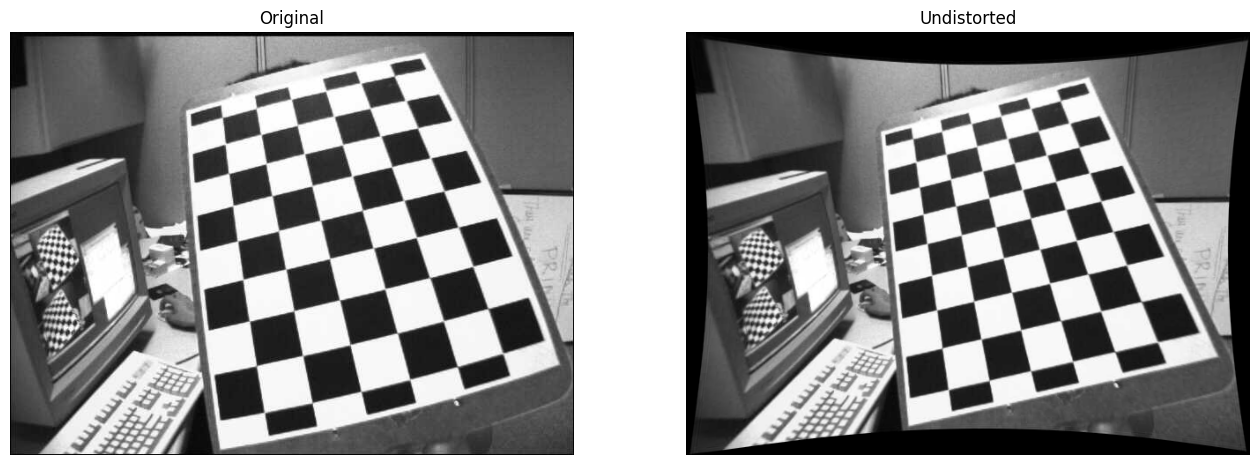

In [ ]:
# ============================================================
# COMPARE ORIGINAL AND UNDISTORTED IMAGES
# ============================================================

plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(dst_rgb)
plt.title("Undistorted")
plt.axis("off")

plt.show()

In [ ]:
# ============================================================
# SAVE UNDISTORTED IMAGE
# ============================================================

output_filename = "undistorted_image.jpg"

cv2.imwrite(
    output_filename,
    dst
)

print("Saved:", output_filename)

Saved: undistorted_image.jpg


In [ ]:
from google.colab import files

files.download("undistorted_image.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>